In [35]:
import pandas as pd
import numpy as np
data=pd.read_csv("twitter_training.csv",header=None,
names=["tweet_id","entity","sentiment","text"])

In [2]:
from sklearn.model_selection import train_test_split
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

In [3]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 74682 entries, 0 to 74681
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   tweet_id   74682 non-null  int64 
 1   entity     74682 non-null  object
 2   sentiment  74682 non-null  object
 3   text       73996 non-null  object
dtypes: int64(1), object(3)
memory usage: 2.3+ MB


In [4]:
df=data

In [5]:
df.isnull().sum().sum()

np.int64(686)

In [6]:
df

,tweet_id,entity,sentiment,text
0,2401,Borderlands,Positive,im getting on borderlands and i will murder yo...
1,2401,Borderlands,Positive,I am coming to the borders and I will kill you...
2,2401,Borderlands,Positive,im getting on borderlands and i will kill you ...
3,2401,Borderlands,Positive,im coming on borderlands and i will murder you...
4,2401,Borderlands,Positive,im getting on borderlands 2 and i will murder ...
...,...,...,...,...
74677,9200,Nvidia,Positive,Just realized that the Windows partition of my...
74678,9200,Nvidia,Positive,Just realized that my Mac window partition is ...
74679,9200,Nvidia,Positive,Just realized the windows partition of my Mac ...
74680,9200,Nvidia,Positive,Just realized between the windows partition of...


In [7]:
df.fillna(0, inplace=True)

In [20]:

valid = ["Negative", "Neutral", "Positive"]
df= df[df["sentiment"].isin(valid)]

In [21]:
sent_map = {"Negative":0, "Neutral":1, "Positive":2}
df["label"] = df["sentiment"].map(sent_map)

C:\Users\admin\AppData\Local\Temp\ipykernel_11792\720398116.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["label"] = df["sentiment"].map(sent_map)


In [22]:
from sklearn.model_selection import train_test_split

In [23]:
X_train, X_test, y_train, y_test = train_test_split(
    df["text"], df["label"], test_size=0.2, random_state=42
)

In [24]:
X_train = X_train.astype(str)
X_test = X_test.astype(str)

In [25]:
X_train = X_train.fillna("").astype(str)
X_test = X_test.fillna("").astype(str)

In [26]:
tokenizer = Tokenizer(num_words=20000, oov_token="<OOV>")
tokenizer.fit_on_texts(X_train)

X_train_seq = tokenizer.texts_to_sequences(X_train)
X_test_seq = tokenizer.texts_to_sequences(X_test)

max_len = 40
X_train_pad = pad_sequences(X_train_seq, maxlen=max_len, padding="post")
X_test_pad = pad_sequences(X_test_seq, maxlen=max_len, padding="post")

In [27]:
df

,tweet_id,entity,sentiment,text,label
0,2401,Borderlands,Positive,im getting on borderlands and i will murder yo...,2
1,2401,Borderlands,Positive,I am coming to the borders and I will kill you...,2
2,2401,Borderlands,Positive,im getting on borderlands and i will kill you ...,2
3,2401,Borderlands,Positive,im coming on borderlands and i will murder you...,2
4,2401,Borderlands,Positive,im getting on borderlands 2 and i will murder ...,2
...,...,...,...,...,...
74677,9200,Nvidia,Positive,Just realized that the Windows partition of my...,2
74678,9200,Nvidia,Positive,Just realized that my Mac window partition is ...,2
74679,9200,Nvidia,Positive,Just realized the windows partition of my Mac ...,2
74680,9200,Nvidia,Positive,Just realized between the windows partition of...,2


In [28]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, Dense

model = Sequential([
    Embedding(input_dim=20000, output_dim=64, input_length=max_len),
    SimpleRNN(64, return_sequences=False),
    Dense(32, activation="relu"),
    Dense(3, activation="softmax")
])

c:\Users\admin\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\core\embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


In [29]:
model.compile(
    loss="sparse_categorical_crossentropy",
    optimizer="adam",
    metrics=["accuracy"]
)

In [30]:
# Explicitly build the model before printing the summary
model.build(input_shape=(None, max_len))
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ (None, 40, 64)         │     1,280,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_1 (SimpleRNN)        │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 3)              │            99 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,290,435 (4.92 MB)

 Trainable params: 1,290,435 (4.92 MB)

 Non-trainable params: 0 (0.00 B)

In [31]:
history=model.fit(
    X_train_pad, y_train,
    validation_split=0.2,
    epochs=5,
    batch_size=64
)

loss, acc = model.evaluate(X_test_pad, y_test)
print("Test Accuracy:", acc)

Epoch 1/5
617/617 ━━━━━━━━━━━━━━━━━━━━ 20s 30ms/step - accuracy: 0.6425 - loss: 0.7995 - val_accuracy: 0.7657 - val_loss: 0.6024
Epoch 2/5
617/617 ━━━━━━━━━━━━━━━━━━━━ 14s 23ms/step - accuracy: 0.8441 - loss: 0.4062 - val_accuracy: 0.8241 - val_loss: 0.4645
Epoch 3/5
617/617 ━━━━━━━━━━━━━━━━━━━━ 14s 23ms/step - accuracy: 0.9026 - loss: 0.2540 - val_accuracy: 0.8556 - val_loss: 0.3909
Epoch 4/5
617/617 ━━━━━━━━━━━━━━━━━━━━ 14s 22ms/step - accuracy: 0.9291 - loss: 0.1805 - val_accuracy: 0.8500 - val_loss: 0.4069
Epoch 5/5
617/617 ━━━━━━━━━━━━━━━━━━━━ 14s 22ms/step - accuracy: 0.9394 - loss: 0.1515 - val_accuracy: 0.8559 - val_loss: 0.4257
386/386 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8505 - loss: 0.4412
Test Accuracy: 0.8504741191864014


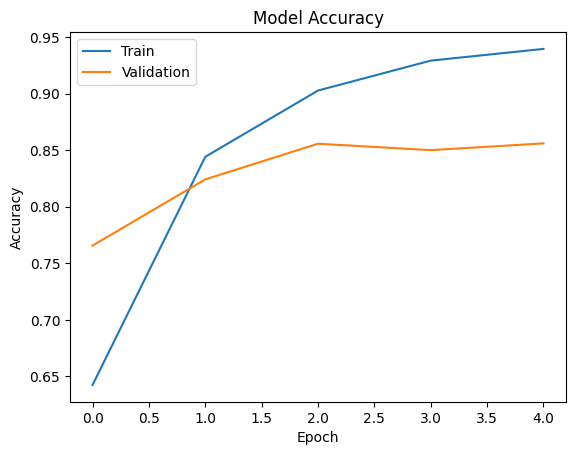

In [32]:
import matplotlib.pyplot as plt
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')

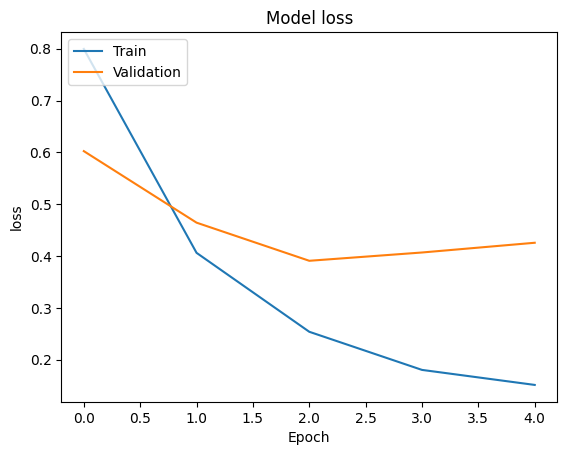

In [33]:
import matplotlib.pyplot as plt
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model loss')
plt.ylabel('loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')

In [36]:
from sklearn.metrics import confusion_matrix, classification_report
y_pred = model.predict(X_test_pad)
y_pred_labels = np.argmax(y_pred, axis=1)
cm = confusion_matrix(y_test, y_pred_labels)
print(classification_report(y_test, y_pred_labels))

386/386 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
              precision    recall  f1-score   support

           0       0.85      0.89      0.87      4509
           1       0.85      0.81      0.83      3650
           2       0.85      0.84      0.84      4180

    accuracy                           0.85     12339
   macro avg       0.85      0.85      0.85     12339
weighted avg       0.85      0.85      0.85     12339



In [ ]:
from tensorflow.keras.layers import Embedding, SimpleRNN, Dense,LSTM

In [38]:
model = Sequential([
    Embedding(input_dim=20000, output_dim=64, input_length=max_len),
    LSTM(64, return_sequences=False),
    Dense(32, activation="relu"),
    Dense(3, activation="softmax")
])

model.compile(
    loss="sparse_categorical_crossentropy",
    optimizer="adam",
    metrics=["accuracy"]
)

c:\Users\admin\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\core\embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


In [39]:
# Explicitly build the model before printing the summary
model.build(input_shape=(None, max_len))
model.summary()

history = model.fit(
    X_train_pad, y_train,
    validation_split=0.2,
    epochs=5,
    batch_size=64
)

loss, acc = model.evaluate(X_test_pad, y_test)
print("Test Accuracy:", acc)

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_2 (Embedding)         │ (None, 40, 64)         │     1,280,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 64)             │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 3)              │            99 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,315,203 (5.02 MB)

 Trainable params: 1,315,203 (5.02 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/5
617/617 ━━━━━━━━━━━━━━━━━━━━ 23s 34ms/step - accuracy: 0.6082 - loss: 0.8417 - val_accuracy: 0.7492 - val_loss: 0.6147
Epoch 2/5
617/617 ━━━━━━━━━━━━━━━━━━━━ 23s 37ms/step - accuracy: 0.8203 - loss: 0.4690 - val_accuracy: 0.8263 - val_loss: 0.4692
Epoch 3/5
617/617 ━━━━━━━━━━━━━━━━━━━━ 21s 35ms/step - accuracy: 0.8844 - loss: 0.3077 - val_accuracy: 0.8484 - val_loss: 0.4080
Epoch 4/5
617/617 ━━━━━━━━━━━━━━━━━━━━ 22s 36ms/step - accuracy: 0.9070 - loss: 0.2388 - val_accuracy: 0.8619 - val_loss: 0.3747
Epoch 5/5
617/617 ━━━━━━━━━━━━━━━━━━━━ 21s 34ms/step - accuracy: 0.9202 - loss: 0.2006 - val_accuracy: 0.8521 - val_loss: 0.4186
386/386 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.8530 - loss: 0.4094
Test Accuracy: 0.8529864549636841


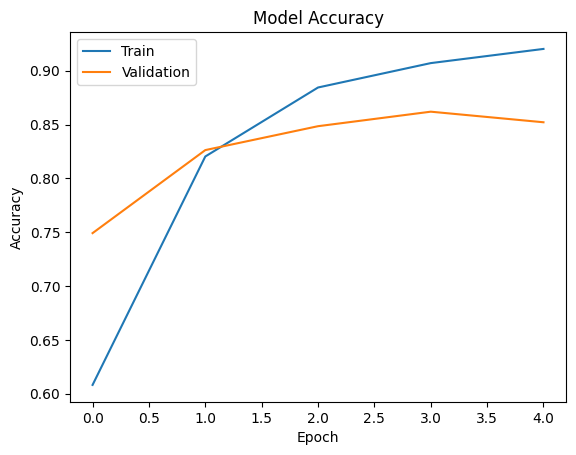

In [40]:
import matplotlib.pyplot as plt
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')

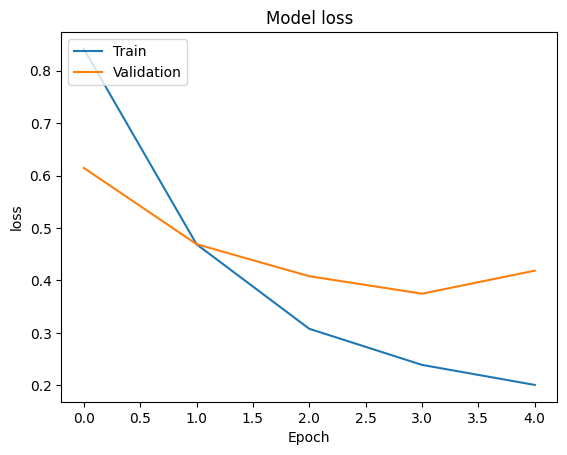

In [41]:
import matplotlib.pyplot as plt
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model loss')
plt.ylabel('loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')

In [42]:
from tensorflow.keras.layers import Embedding, SimpleRNN, Dense,LSTM,Bidirectional

In [43]:
model = Sequential([
    Embedding(input_dim=20000, output_dim=64, input_length=max_len),
    Bidirectional(LSTM(64, return_sequences=False)),
    Dense(32, activation="relu"),
    Dense(3, activation="softmax")
])

model.compile(
    loss="sparse_categorical_crossentropy",
    optimizer="adam",
    metrics=["accuracy"]
)

c:\Users\admin\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\core\embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


In [44]:
# Explicitly build the model before printing the summary
model.build(input_shape=(None, max_len))
model.summary()

history = model.fit(
    X_train_pad, y_train,
    validation_split=0.2,
    epochs=5,
    batch_size=64
)

loss, acc = model.evaluate(X_test_pad, y_test)
print("Test Accuracy:", acc)

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_3 (Embedding)         │ (None, 40, 64)         │     1,280,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ (None, 128)            │        66,048 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 32)             │         4,128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 3)              │            99 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,350,275 (5.15 MB)

 Trainable params: 1,350,275 (5.15 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/5
617/617 ━━━━━━━━━━━━━━━━━━━━ 34s 46ms/step - accuracy: 0.7035 - loss: 0.6807 - val_accuracy: 0.8120 - val_loss: 0.4765
Epoch 2/5
617/617 ━━━━━━━━━━━━━━━━━━━━ 29s 47ms/step - accuracy: 0.8786 - loss: 0.3098 - val_accuracy: 0.8624 - val_loss: 0.3646
Epoch 3/5
617/617 ━━━━━━━━━━━━━━━━━━━━ 28s 45ms/step - accuracy: 0.9226 - loss: 0.1959 - val_accuracy: 0.8765 - val_loss: 0.3542
Epoch 4/5
617/617 ━━━━━━━━━━━━━━━━━━━━ 28s 45ms/step - accuracy: 0.9374 - loss: 0.1518 - val_accuracy: 0.8819 - val_loss: 0.3535
Epoch 5/5
617/617 ━━━━━━━━━━━━━━━━━━━━ 28s 46ms/step - accuracy: 0.9489 - loss: 0.1228 - val_accuracy: 0.8885 - val_loss: 0.3420
386/386 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.8819 - loss: 0.3473
Test Accuracy: 0.8819191455841064


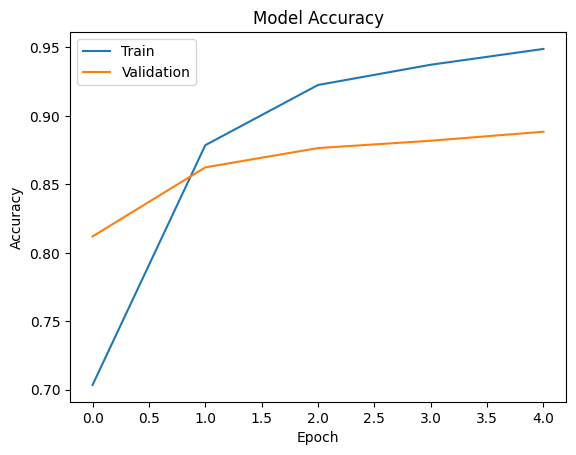

In [45]:
import matplotlib.pyplot as plt
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')

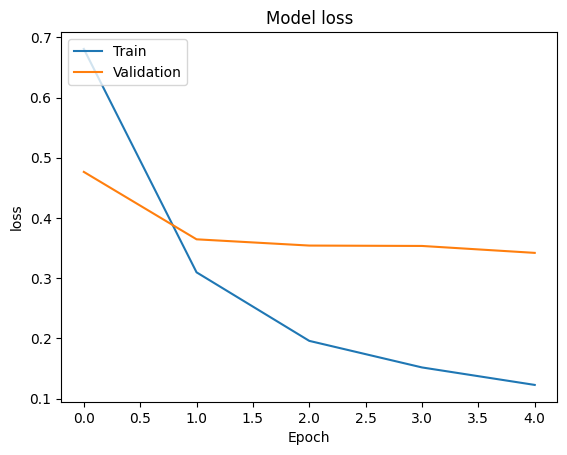

In [46]:
import matplotlib.pyplot as plt
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model loss')
plt.ylabel('loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')

In [47]:
from tensorflow.keras.layers import Embedding, SimpleRNN, Dense,LSTM,Bidirectional,GRU

In [48]:
model = Sequential([
    Embedding(input_dim=20000, output_dim=64, input_length=max_len),
    GRU(64, return_sequences=False),
    Dense(32, activation="relu"),
    Dense(3, activation="softmax")
])

model.compile(
    loss="sparse_categorical_crossentropy",
    optimizer="adam",
    metrics=["accuracy"]
)

c:\Users\admin\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\core\embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


In [49]:
# Explicitly build the model before printing the summary
model.build(input_shape=(None, max_len))
model.summary()

history = model.fit(
    X_train_pad, y_train,
    validation_split=0.2,
    epochs=5,
    batch_size=64
)

loss, acc = model.evaluate(X_test_pad, y_test)
print("Test Accuracy:", acc)

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_4 (Embedding)         │ (None, 40, 64)         │     1,280,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru (GRU)                       │ (None, 64)             │        24,960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 3)              │            99 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,307,139 (4.99 MB)

 Trainable params: 1,307,139 (4.99 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/5
617/617 ━━━━━━━━━━━━━━━━━━━━ 27s 39ms/step - accuracy: 0.4797 - loss: 0.9787 - val_accuracy: 0.7295 - val_loss: 0.6568
Epoch 2/5
617/617 ━━━━━━━━━━━━━━━━━━━━ 23s 37ms/step - accuracy: 0.8244 - loss: 0.4511 - val_accuracy: 0.8404 - val_loss: 0.4038
Epoch 3/5
617/617 ━━━━━━━━━━━━━━━━━━━━ 23s 37ms/step - accuracy: 0.9021 - loss: 0.2485 - val_accuracy: 0.8694 - val_loss: 0.3481
Epoch 4/5
617/617 ━━━━━━━━━━━━━━━━━━━━ 23s 37ms/step - accuracy: 0.9261 - loss: 0.1842 - val_accuracy: 0.8774 - val_loss: 0.3611
Epoch 5/5
617/617 ━━━━━━━━━━━━━━━━━━━━ 23s 37ms/step - accuracy: 0.9376 - loss: 0.1471 - val_accuracy: 0.8792 - val_loss: 0.3588
386/386 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.8769 - loss: 0.3509
Test Accuracy: 0.8768944144248962


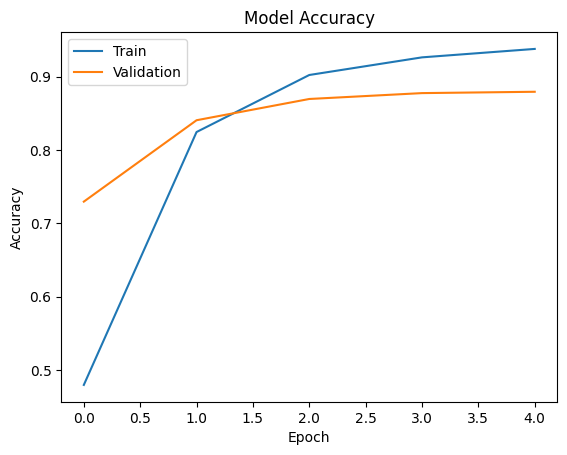

In [50]:
import matplotlib.pyplot as plt
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')

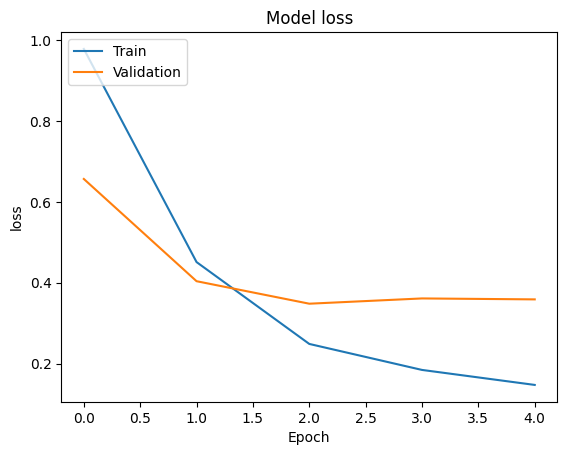

In [51]:
import matplotlib.pyplot as plt
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model loss')
plt.ylabel('loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')